In [ ]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
## READING DATA
data_dir = Path("data")

dfs = []
for csv_file in data_dir.glob("*.csv"):
    df = pd.read_csv(csv_file)
    df["_source_file"] = csv_file.name  # optional: track which file each row came from
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(dfs)} files → {combined.shape[0]} rows, {combined.shape[1]} columns")

Loaded 10 files → 22218 rows, 8 columns


In [ ]:
# CLEANING

# combined df keeps players with 0 or 1 year of experience, rookies are considered to have 0 years of experience
# separates by seasons
combined.loc[combined['Experience'] == 'Rook', 'Experience'] = '0'
combined['Experience'] = combined['Experience'].astype(int)
combined = combined[(combined['Experience'] == 0) | (combined['Experience'] == 1)]

# summed_av is the sum of AV for each player across all seasons, so we can see how much AV a player has accumulated in their first two seasons
summed_av = combined.groupby('Player')['AV'].sum().reset_index()

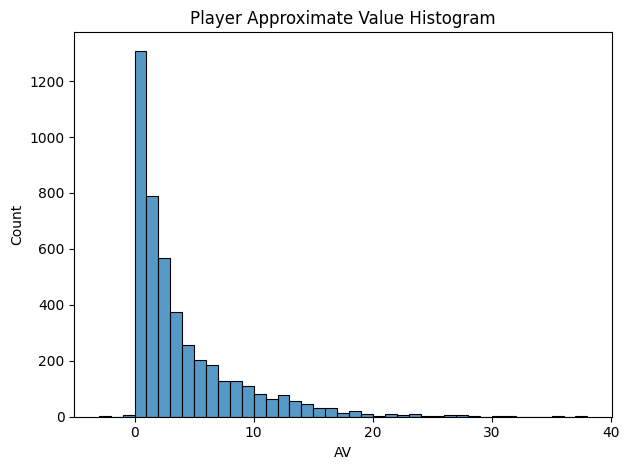

In [50]:
sns.histplot(
    data=summed_av,
    x='AV',
    bins = np.arange(summed_av['AV'].min(), summed_av['AV'].max() + 2),
)

plt.title('Player Approximate Value Histogram')
plt.tight_layout()
plt.show()

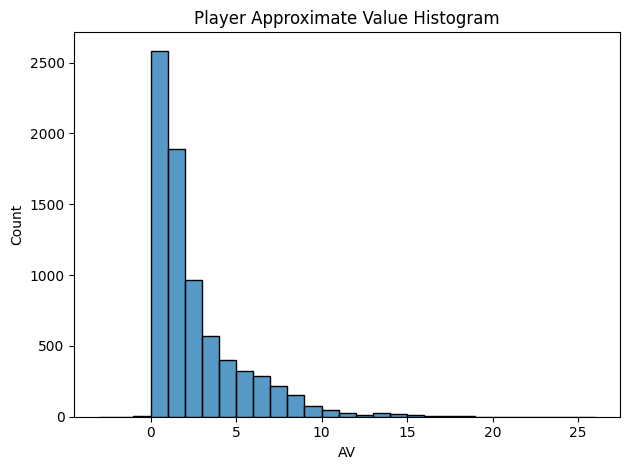

In [51]:
sns.histplot(
    data=combined,
    x='AV',
    bins = np.arange(combined['AV'].min(), combined['AV'].max() + 2),
)

plt.title('Player Approximate Value Histogram')
plt.tight_layout()
plt.show()